# STAE321 Figures 11 & 12: Star and BH Trajectory Plots
Reproduces Figures 11 (aerodynamic drag on stars) and 12 (dynamical friction on BHs) from arXiv:2308.09129v5.

In [1]:
import sys, os, subprocess, glob
sys.path.insert(0, os.path.abspath(".."))
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import multiprocessing as mp
from tqdm.notebook import tqdm

# This notebook lives in verify_gas_drag/.
# The C++ executables are compiled and run from HERE (verify_gas_drag/).
# They use '../src/...' for the disk file and 'fig11/' / 'fig12/' for output,
# both of which are correct when cwd = verify_gas_drag/.
HERE = Path(os.path.abspath(""))          # verify_gas_drag/
# spacehub_calc.py is in the parent project root (3 levels up from here)
ROOT = HERE.parent.parent.parent if HERE.name == "verify_gas_drag" else HERE
sys.path.insert(0, str(ROOT))             # make spacehub_calc importable

from spacehub_calc import TwoBodyOrbit

print(f"Running from: {HERE}")
assert (HERE / "stae321-11.cpp").exists(), "Expected to be in verify_gas_drag/"

Running from: /home/mars/Computing/AGN/SpaceHub-Tinkering/SpaceHub/test/verify_gas_drag


## Compile

In [2]:
if False:
    for src, exe in [("stae321-11.cpp", "stae321-11"),
                     ("stae321-12.cpp", "stae321-12")]:
        print(f"Compiling {src}...")
        subprocess.run(
            ["g++", "-std=c++17", "-O3", "-pthread", src, "-o", exe],
            cwd=HERE, check=True
        )
    print("Compilation complete.")
else:
    print("Compilation disabled (if False). Using pre-compiled executables.")

Compilation disabled (if False). Using pre-compiled executables.


## Run Simulations

In [3]:


inclinations = [5 + 17*i for i in range(0, 11)]
print(f"Inclinations: {inclinations}")
if False:
    # Ensure output directories exist (C++ won't create them)
    (HERE / "fig11").mkdir(exist_ok=True)
    (HERE / "fig12").mkdir(exist_ok=True)

    def _run(args):
        """Pool worker: (exe, inc, cwd_str) → (inc, ok, stderr)."""
        exe, inc, cwd_str = args
        result = subprocess.run(
            [f"./{exe}", str(inc)],
            cwd=cwd_str, capture_output=True, text=True
        )
        return inc, result.returncode == 0, result.stderr

    N_WORKERS = 6
    HERE_STR = str(HERE)  # this is thread safe and theoretically allows the notebook to be moved

    for label, exe in [("Fig 11 – AeroDrag", "stae321-11"),
                    ("Fig 12 – DynFric",  "stae321-12")]:
        tasks = [(exe, inc, HERE_STR) for inc in inclinations]
        with mp.Pool(N_WORKERS) as pool:
            for inc, ok, err in tqdm(
                pool.imap_unordered(_run, tasks),
                total=len(tasks), desc=label
            ):
                if not ok:
                    print(f"  WARN i={inc}°: {err.strip()[-200:]}")

Inclinations: [5, 22, 39, 56, 73, 90, 107, 124, 141, 158, 175]


## Load Orbital Data

In [ ]:
def load_orbits(pattern):
    
    orbits = {}
    for fpath in sorted(glob.glob(str(HERE / pattern))):
        stem = Path(fpath).stem            # e.g. 'AeroDrag-i5'
        inc = int(float(stem.split("-i")[-1]))
        orbits[inc] = TwoBodyOrbit(fpath, mute=True)
    return orbits

orbits_fig11 = load_orbits("fig11/AeroDrag-i*.dat")
orbits_fig12 = load_orbits("fig12/DynFriction-i*.dat")

print(f"Fig 11 loaded: {sorted(orbits_fig11)}")
print(f"Fig 12 loaded: {sorted(orbits_fig12)}")

Calculated c0 values are within 2.49e+03 of constant (maximum - minimum)
Calculated c0 values are within 2.536e+03 of constant (maximum - minimum)
Calculated c0 values are within 7.757e+07 of constant (maximum - minimum)
Calculated c0 values are within 3.343e+03 of constant (maximum - minimum)
Calculated c0 values are within 6.553e+03 of constant (maximum - minimum)
Calculated c0 values are within 3.668e+06 of constant (maximum - minimum)
Calculated c0 values are within 4.393e+06 of constant (maximum - minimum)
Calculated c0 values are within 4.603e+06 of constant (maximum - minimum)
Calculated c0 values are within 2.669e+06 of constant (maximum - minimum)
Calculated c0 values are within 146.2 of constant (maximum - minimum)
Fig 11 loaded: [5, 22, 39, 56, 73]
Fig 12 loaded: [5, 22, 39, 56, 73]


## Plotting

In [5]:
sns.set_style("whitegrid")
AU_PER_PC = 206264.806

# ── Per-panel axis configuration ─────────────────────────────────────────────
# Panels listed in row-major order: I(t), a(t), e(t), e(a), a(I), e(I)
# xscale / yscale : "log" or "linear"
# xlim / ylim     : (lo, hi) to fix limits, or None for auto
AXIS_CONFIG = [
    dict(xscale="log",    yscale="linear", xlim=None, ylim=None),  # [0,0] I(t)
    dict(xscale="log",    yscale="log",    xlim=None, ylim=None),  # [0,1] a(t)
    dict(xscale="log",    yscale="log", xlim=None, ylim=None),  # [0,2] e(t)
    dict(xscale="log",    yscale="log", xlim=None, ylim=None),  # [1,0] e(a)
    dict(xscale="linear", yscale="log",    xlim=None, ylim=None),  # [1,1] a(I)
    dict(xscale="log", yscale="linear", xlim=None, ylim=None),  # [1,2] e(I)
]
# ─────────────────────────────────────────────────────────────────────────────

def plot_6panel(orbits_dict, title_prefix, e0, cos_omega):

    cmap = cm.rainbow
    inc_values = sorted(orbits_dict)
    norm = plt.Normalize(vmin=min(inc_values), vmax=max(inc_values))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for inc in inc_values:
        orb = orbits_dict[inc]
        t = orb.years
        a = np.array(orb.semiMajorAxis) / AU_PER_PC   # AU → pc
        e = np.array(orb.eccentricity)
        I = np.array(orb.inclination_deg)
        c = cmap(norm(inc))

        axes[0, 0].plot(t, I, color=c, lw=1.2)
        axes[0, 1].plot(t, a, color=c, lw=1.2)
        axes[0, 2].plot(t, e, color=c, lw=1.2)
        axes[1, 0].plot(a, e, color=c, lw=1.2)
        axes[1, 1].plot(I, a, color=c, lw=1.2)
        axes[1, 2].plot(I, e, color=c, lw=1.2)

    panel_labels = [
        ("$t$ [yr]",  "$I$ [deg]"),
        ("$t$ [yr]",  "$a$ [pc]"),
        ("$t$ [yr]",  "$e$"),
        ("$a$ [pc]",  "$e$"),
        ("$I$ [deg]", "$a$ [pc]"),
        ("$I$ [deg]", "$e$"),
    ]
    for ax, cfg, (xl, yl) in zip(axes.flat, AXIS_CONFIG, panel_labels):
        ax.set(xlabel=xl, ylabel=yl, xscale=cfg["xscale"], yscale=cfg["yscale"])
        if cfg["xlim"] is not None:
            ax.set_xlim(cfg["xlim"])
        if cfg["ylim"] is not None:
            ax.set_ylim(cfg["ylim"])

    axes[0, 1].set_title(
        f"{title_prefix}\u2003$e_0={e0}$,\u2003$\\cos\\omega_0={cos_omega}$",
        pad=8, fontsize=11
    )

    plt.tight_layout()
    return fig, axes

### Figure 11 – Aerodynamic Drag (Stars)

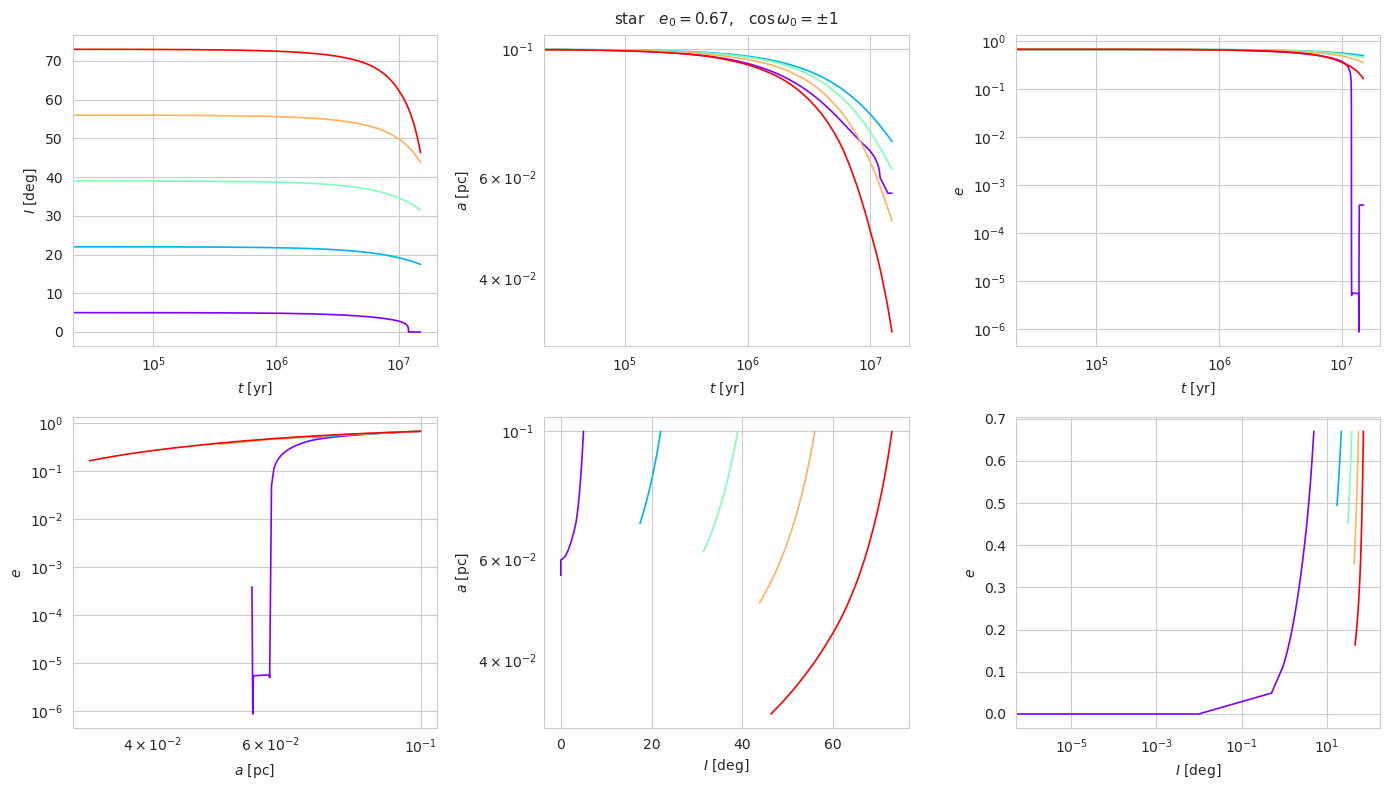

In [6]:
fig11, axes = plot_6panel(orbits_fig11, "star", e0=0.67, cos_omega="{\\pm}1")
fig11.show()

### Figure 12 – Dynamical Friction (BHs)

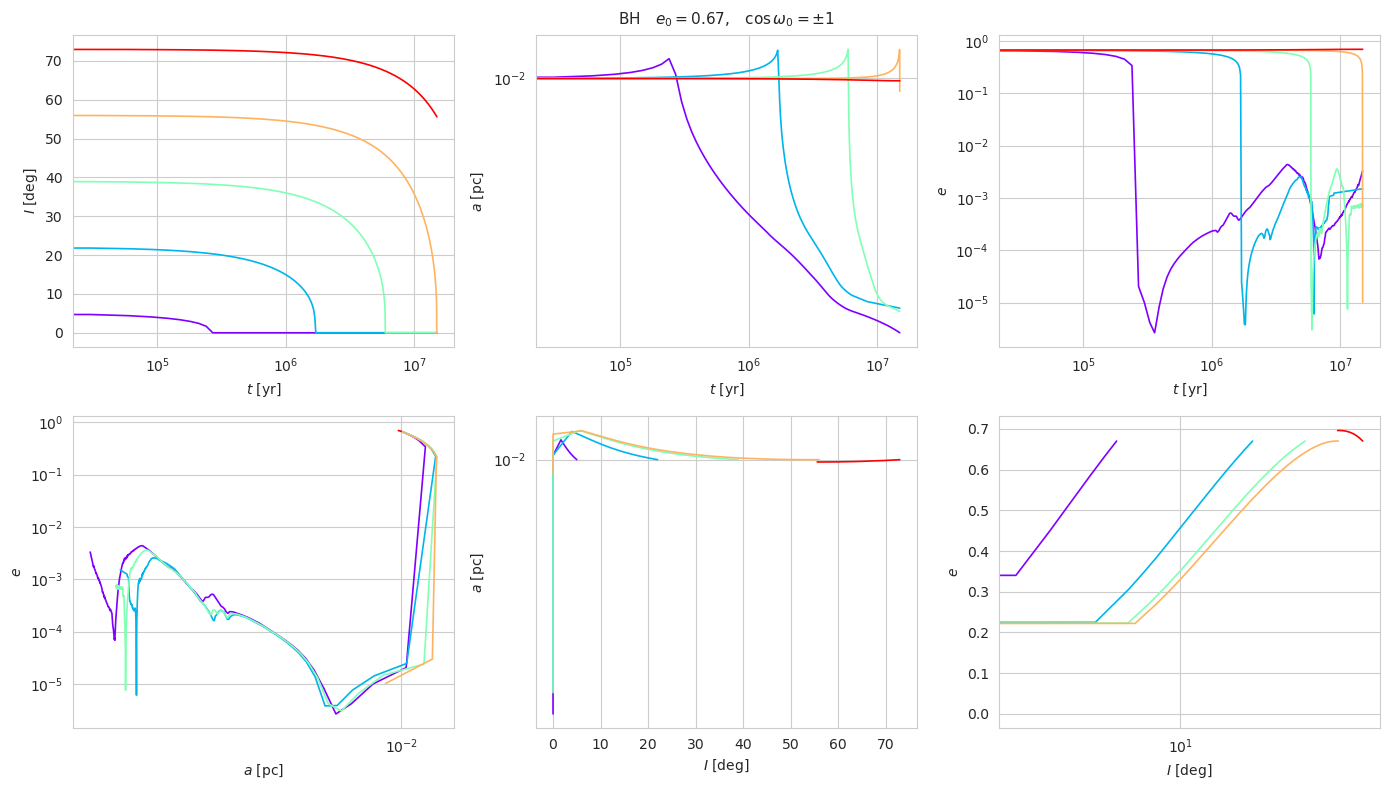

In [7]:
if orbits_fig12:
    fig12 = plot_6panel(orbits_fig12, "BH", e0=0.67, cos_omega="{\\pm}1")
    plt.show()
else:
    print("No fig12 data found.")

---
## pagn Disks
Load pagn-based simulation outputs (Sirko-Goodman model, α=0.01, le=1.0) and overlay on disktab results.

In [8]:
# Load pagn simulation outputs (run after run_overnight_pagn.sh completes)
#orbits_fig11_pagn = load_orbits("fig11-pagn/AeroDrag-i*.dat")
orbits_fig12_pagn = load_orbits("fig12-pagn/DynFriction-i*.dat")

#print(f"Fig 11 pagn loaded: {sorted(orbits_fig11_pagn)}")
print(f"Fig 12 pagn loaded: {sorted(orbits_fig12_pagn)}")

Calculated c0 values are within 441.6 of constant (maximum - minimum)
Calculated c0 values are within 522.0 of constant (maximum - minimum)
Calculated c0 values are within 675.6 of constant (maximum - minimum)
Calculated c0 values are within 1.059e+03 of constant (maximum - minimum)
Calculated c0 values are within 1.373e+03 of constant (maximum - minimum)
Calculated c0 values are within 4.893e+06 of constant (maximum - minimum)
Calculated c0 values are within 1.565e+06 of constant (maximum - minimum)
Calculated c0 values are within 4.439e+06 of constant (maximum - minimum)
Calculated c0 values are within 1.687e+06 of constant (maximum - minimum)
Calculated c0 values are within 145.9 of constant (maximum - minimum)
Fig 12 pagn loaded: [5, 22, 39, 56, 73, 107, 124, 141, 158, 175]


In [ ]:

def plot_6panel_comparison(orbits_disktab, orbits_pagn, title_prefix, e0, cos_omega, plot_disktab=False):
    """6-panel plot overlaying disktab (solid) and pagn (dashed) results."""
    cmap = cm.rainbow
    inc_values = sorted(set(orbits_disktab) | set(orbits_pagn)) #Needed to handle sims that failed causing differing inclination arrays
    norm = plt.Normalize(vmin=min(inc_values), vmax=max(inc_values))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    
    for inc in inc_values:
        c = cmap(norm(inc))
        # Disktab (solid)
        if plot_disktab:
            if inc in orbits_disktab:
                orb = orbits_disktab[inc]
                t, a, e, I = orb.years, np.array(orb.semiMajorAxis)/AU_PER_PC, np.array(orb.eccentricity), np.array(orb.inclination_deg)
                axes[0,0].plot(t, I, color=c, lw=1.2, alpha=0.5)
                axes[0,1].plot(t, a, color=c, lw=1.2, alpha=0.5)
                axes[0,2].plot(t, e, color=c, lw=1.2, alpha=0.5)
                axes[1,0].plot(a, e, color=c, lw=1.2, alpha=0.5)
                axes[1,1].plot(I, a, color=c, lw=1.2, alpha=0.5)
                axes[1,2].plot(I, e, color=c, lw=1.2, alpha=0.5)
        # pagn (dashed)
        if inc in orbits_pagn:
            orb = orbits_pagn[inc]
            t, a, e, I = orb.years, np.array(orb.semiMajorAxis)/AU_PER_PC, np.array(orb.eccentricity), np.array(orb.inclination_deg)
            axes[0,0].plot(t, I, color=c, lw=1.5, ls='--')
            axes[0,1].plot(t, a, color=c, lw=1.5, ls='--')
            axes[0,2].plot(t, e, color=c, lw=1.5, ls='--')
            axes[1,0].plot(a, e, color=c, lw=1.5, ls='--')
            axes[1,1].plot(I, a, color=c, lw=1.5, ls='--')
            axes[1,2].plot(I, e, color=c, lw=1.5, ls='--')

    panel_labels = [
        ("$t$ [yr]","$I$ [deg]"), ("$t$ [yr]","$a$ [pc]"), ("$t$ [yr]","$e$"),
        ("$a$ [pc]","$e$"), ("$I$ [deg]","$a$ [pc]"), ("$I$ [deg]","$e$"),
    ]
    for ax, cfg, (xl, yl) in zip(axes.flat, AXIS_CONFIG, panel_labels):
        ax.set(xlabel=xl, ylabel=yl, xscale=cfg["xscale"], yscale=cfg["yscale"])

    # Legend: solid=disktab, dashed=pagn
    from matplotlib.lines import Line2D
    axes[0,1].legend(
        [Line2D([0],[0], color='gray', lw=1.2), Line2D([0],[0], color='gray', lw=1.5, ls='--')],
        ['disktab (α=0.1)', 'pagn SG (α=0.01)'], fontsize=9, loc='lower left'
    )
    axes[0,1].set_title(f"{title_prefix}  $e_0={e0}$, $\\cos\\omega_0={cos_omega}$", pad=8, fontsize=11)
    plt.tight_layout()
    return fig, axes

### Fig 11 Comparison – Aerodynamic Drag (Stars): disktab vs pagn (alpha=0.01, le=1.0)

In [ ]:
orbits_fig11_pagn = False
if orbits_fig11_pagn:
    fig, _ = plot_6panel_comparison(orbits_fig11, orbits_fig11_pagn, "star", e0=0.67, cos_omega="{\\pm}1")
    plt.show()
else:
    print("No pagn fig11 data")

No pagn fig11 data yet — run run_overnight_pagn.sh first.


### Fig 12 – Dynamical Friction - pagn SG disk

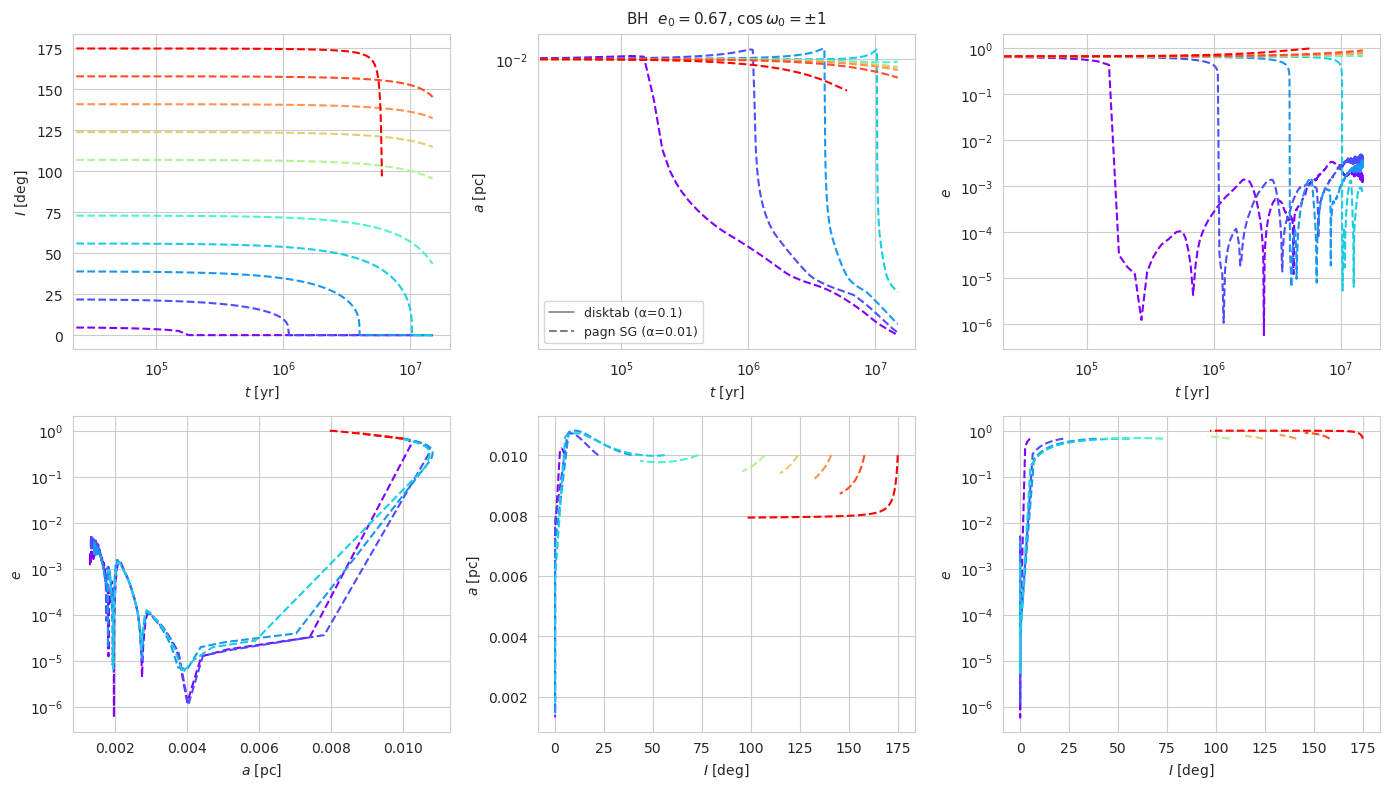

In [ ]:
AXIS_CONFIG = [
    dict(xscale="log",    yscale="linear", xlim=None, ylim=None),  # [0,0] I(t)
    dict(xscale="log",    yscale="log",    xlim=None, ylim=None),  # [0,1] a(t)
    dict(xscale="log",    yscale="log", xlim=None, ylim=None),  # [0,2] e(t)
    dict(xscale="linear",    yscale="log", xlim=None, ylim=None),  # [1,0] e(a)
    dict(xscale="linear", yscale="linear",    xlim=None, ylim=None),  # [1,1] a(I)
    dict(xscale="linear", yscale="log", xlim=None, ylim=None),  # [1,2] e(I)
]

if orbits_fig12_pagn:
    fig, _ = plot_6panel_comparison(orbits_fig12, orbits_fig12_pagn, "BH", e0=0.67, cos_omega="{\\pm}1")
    plt.show()
else:
    print("No pagn fig12 data")